In [18]:
import sys
sys.path.append('../src')
from load_data import load_all
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

clinical, paxhd, paxday, paxhr = load_all()
print(clinical.shape)
clinical.head()

Loading demographics...
Loading cholesterol...
Loading blood pressure...
Loading labs...
Loading questionnaires...
Loading activity data...
Merging clinical data...
Done. Clinical shape: (9756, 12)
(9756, 12)


,SEQN,RIDAGEYR,RIAGENDR,RIDRETH1,LBXTC,LBDHDD,BPXSY1,BPXDI1,LBXGLU,LBXGH,SMQ020,DIQ010
0,62161.0,22.0,1.0,3.0,168.0,41.0,110.0,82.0,92.0,5.1,2.0,2.0
1,62162.0,3.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
2,62163.0,14.0,1.0,5.0,154.0,44.0,112.0,38.0,NaN,5.5,NaN,2.0
3,62164.0,44.0,2.0,3.0,190.0,28.0,116.0,56.0,82.0,4.9,2.0,2.0
4,62165.0,14.0,2.0,4.0,161.0,63.0,110.0,64.0,88.0,5.9,NaN,2.0


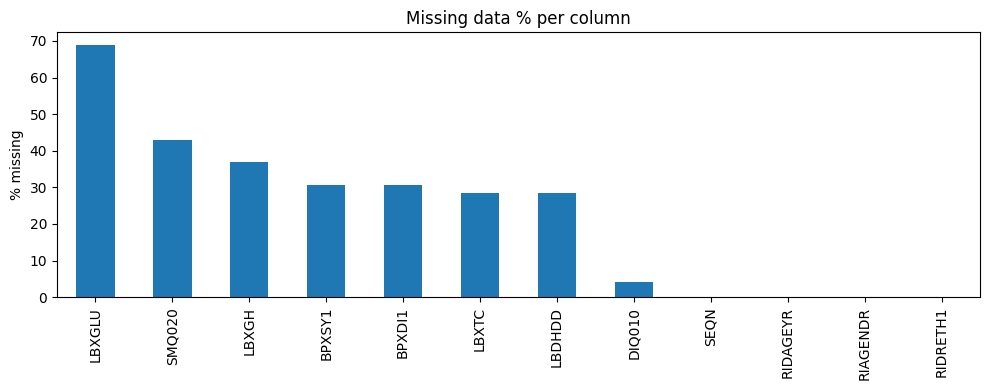

In [19]:
missing = clinical.isnull().sum() / len(clinical) * 100
missing.sort_values(ascending=False).plot(kind='bar', figsize=(10,4))
plt.title('Missing data % per column')
plt.ylabel('% missing')
plt.tight_layout()
plt.savefig('../results/missingness.png')
plt.show()

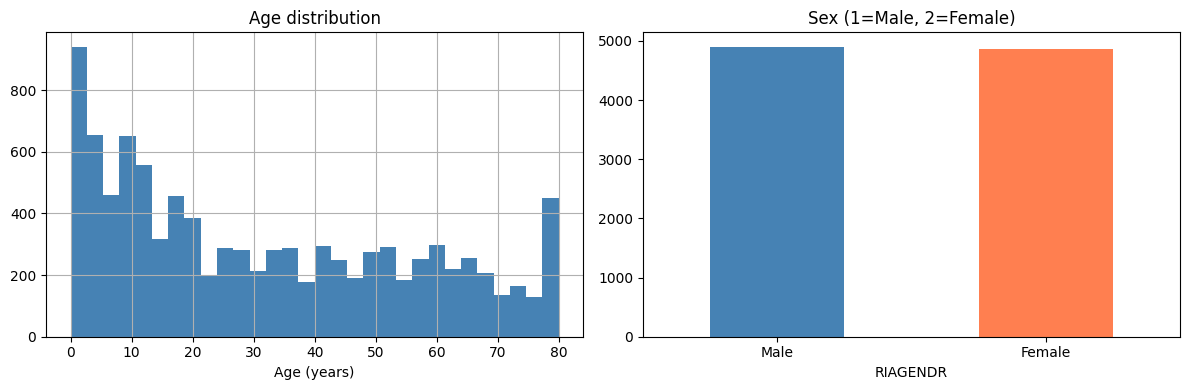

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

clinical['RIDAGEYR'].hist(bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Age distribution')
axes[0].set_xlabel('Age (years)')

clinical['RIAGENDR'].value_counts().plot(kind='bar', ax=axes[1], color=['steelblue','coral'])
axes[1].set_title('Sex (1=Male, 2=Female)')
axes[1].set_xticklabels(['Male','Female'], rotation=0)

plt.tight_layout()
plt.savefig('../results/demographics.png')
plt.show()

In [22]:
print("PAXDAY shape:", paxday.shape)
print("PAXHR shape:", paxhr.shape)
print("\nPAXDAY columns:", paxday.columns.tolist())
print("\nPAXHR columns:", paxhr.columns.tolist())
paxday.head()

PAXDAY shape: (61168, 15)
PAXHR shape: (1307994, 14)

PAXDAY columns: ['SEQN', 'PAXDAYD', 'PAXDAYWD', 'PAXSSNDP', 'PAXMSTD', 'PAXTMD', 'PAXAISMD', 'PAXVMD', 'PAXMTSD', 'PAXWWMD', 'PAXSWMD', 'PAXNWMD', 'PAXUMD', 'PAXLXSD', 'PAXQFD']

PAXHR columns: ['SEQN', 'PAXDAYH', 'PAXDAYWH', 'PAXSSNHP', 'PAXTMH', 'PAXAISMH', 'PAXVMH', 'PAXMTSH', 'PAXWWMH', 'PAXSWMH', 'PAXNWMH', 'PAXUMH', 'PAXLXSH', 'PAXQFH']


,SEQN,PAXDAYD,PAXDAYWD,PAXSSNDP,PAXMSTD,PAXTMD,PAXAISMD,PAXVMD,PAXMTSD,PAXWWMD,PAXSWMD,PAXNWMD,PAXUMD,PAXLXSD,PAXQFD
0,62161.0,1,7,5.397605e-79,12:30:00,690.0,1426946.0,690.0,4636.399,508.0,139.0,5.397605e-79,43.0,49185.11,5.397605e-79
1,62161.0,2,1,3.312000e+06,0:00:00,1440.0,3123802.0,1440.0,12531.363,816.0,548.0,5.397605e-79,76.0,433309.24,5.397605e-79
2,62161.0,3,2,1.022400e+07,0:00:00,1440.0,2779464.0,1440.0,14013.228,921.0,462.0,5.397605e-79,57.0,475977.11,5.397605e-79
3,62161.0,4,3,1.713600e+07,0:00:00,1440.0,2724602.0,1440.0,16982.386,911.0,472.0,5.397605e-79,57.0,208827.73,5.397605e-79
4,62161.0,5,4,2.404800e+07,0:00:00,1440.0,3144826.0,1440.0,11718.500,854.0,504.0,5.397605e-79,82.0,114269.65,5.397605e-79


In [23]:
# PAXDAYWEAR = valid wear minutes per day
# PAXMSTEP  = step count per day
if 'PAXDAYWEAR' in paxday.columns:
    paxday['PAXDAYWEAR'].hist(bins=40, color='steelblue', figsize=(8,4))
    plt.title('Daily wear time (minutes)')
    plt.xlabel('Minutes worn per day')
    plt.savefig('../results/wear_time.png')
    plt.show()

paxday.describe()

,SEQN,PAXSSNDP,PAXTMD,PAXAISMD,PAXVMD,PAXMTSD,PAXWWMD,PAXSWMD,PAXNWMD,PAXUMD,PAXLXSD,PAXQFD
count,61168.000000,6.116800e+04,61168.000000,6.116800e+04,6.116800e+04,6.116800e+04,6.116800e+04,6.116800e+04,6.116800e+04,6.116800e+04,6.116800e+04,6.116800e+04
mean,67020.577393,2.339339e+07,1277.250458,2.849805e+06,1.275466e+03,1.136728e+04,7.031142e+02,3.833389e+02,1.447293e+02,4.428353e+01,1.266445e+05,2.060620e+00
std,2810.231500,1.710567e+07,333.717026,1.288327e+06,3.345587e+02,6.843649e+03,3.403690e+02,2.131824e+02,3.284995e+02,2.694968e+01,1.653127e+05,3.918359e+01
min,62161.000000,5.397605e-79,4.000000,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79
25%,64596.000000,8.784000e+06,1440.000000,2.271900e+06,1.434000e+03,6.261296e+03,4.870000e+02,2.770000e+02,5.397605e-79,2.600000e+01,1.473169e+04,5.397605e-79
50%,67024.000000,2.260800e+07,1440.000000,2.771784e+06,1.440000e+03,1.167875e+04,8.460000e+02,4.180000e+02,5.397605e-79,4.200000e+01,6.953508e+04,5.397605e-79
75%,69437.000000,3.787200e+07,1440.000000,3.373374e+06,1.440000e+03,1.610018e+04,9.530000e+02,5.100000e+02,1.000000e+01,6.000000e+01,1.740390e+05,5.397605e-79
max,71916.000000,5.271840e+07,1440.000000,6.912000e+06,1.440000e+03,5.068323e+04,1.437000e+03,1.440000e+03,1.440000e+03,2.880000e+02,1.967563e+06,2.880000e+03


In [24]:
clinical_ids = set(clinical['SEQN'])
pax_ids      = set(paxday['SEQN'])
overlap      = clinical_ids & pax_ids

print(f"Clinical participants:  {len(clinical_ids)}")
print(f"Activity participants:  {len(pax_ids)}")
print(f"Overlap (both):        {len(overlap)}")


Clinical participants:  9756
Activity participants:  6917
Overlap (both):        6917


In [25]:
import sys
sys.path.append('../src')
from framingham import compute_framingham

clinical_scored = compute_framingham(clinical)
print(clinical_scored[['framingham_risk','high_risk']].describe())
print(f"\nHigh risk participants: {clinical_scored['high_risk'].sum()}")
print(f"Low risk participants:  {(clinical_scored['high_risk']==0).sum()}")

       framingham_risk    high_risk
count      3280.000000  3985.000000
mean          0.124041     0.338269
std           0.130089     0.473180
min           0.003199     0.000000
25%           0.032514     0.000000
50%           0.075746     0.000000
75%           0.166027     1.000000
max           0.874671     1.000000

High risk participants: 1348
Low risk participants:  2637


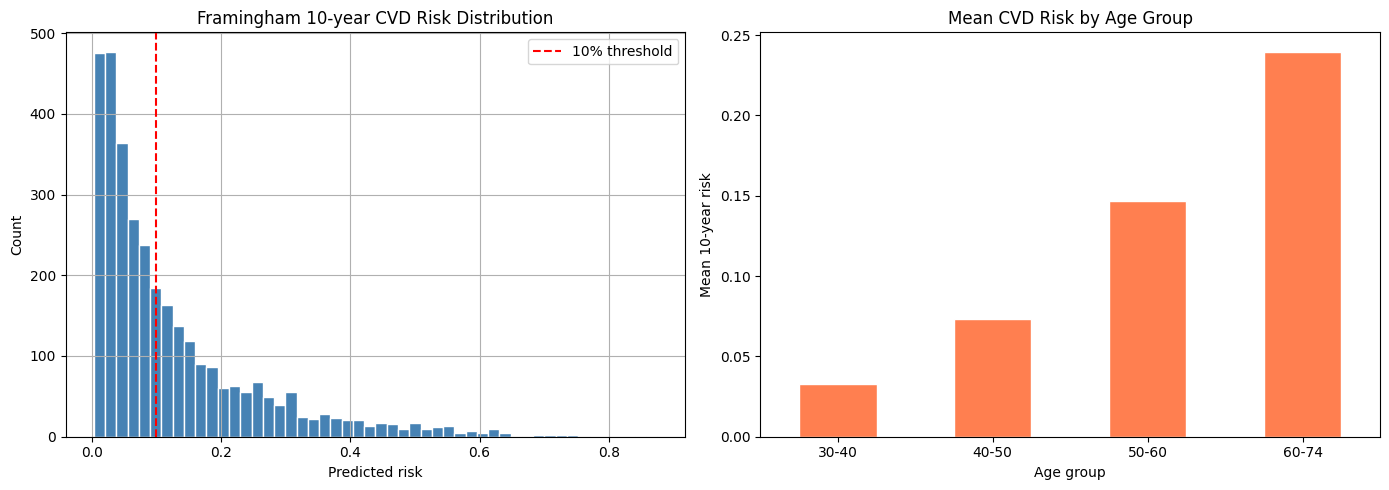

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Risk score distribution
clinical_scored['framingham_risk'].dropna().hist(
    bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(0.10, color='red', linestyle='--', label='10% threshold')
axes[0].set_title('Framingham 10-year CVD Risk Distribution')
axes[0].set_xlabel('Predicted risk')
axes[0].set_ylabel('Count')
axes[0].legend()

# Risk by age group
clinical_scored['age_group'] = pd.cut(
    clinical_scored['RIDAGEYR'],
    bins=[30,40,50,60,74],
    labels=['30-40','40-50','50-60','60-74'])
clinical_scored.groupby('age_group', observed=True)['framingham_risk'].mean().plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Mean CVD Risk by Age Group')
axes[1].set_xlabel('Age group')
axes[1].set_ylabel('Mean 10-year risk')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../results/risk_distribution.png')
plt.show()

In [27]:
from features import build_model_dataset

dataset = build_model_dataset(clinical_scored, paxday, paxhd)
dataset.describe()

Final dataset: 2967 participants, 16 features
High risk: 1216 (41.0%)
Low risk:  1751

Features: ['mean_activity', 'std_activity', 'min_activity', 'max_activity', 'activity_regularity', 'low_activity_days', 'high_activity_days', 'mean_intensity', 'std_intensity', 'mean_wake_mins', 'mean_sleep_mins', 'sleep_ratio', 'mean_nonwear_mins', 'mean_lux', 'std_lux', 'n_valid_days']


,SEQN,RIDAGEYR,RIAGENDR,framingham_risk,high_risk,mean_activity,std_activity,min_activity,max_activity,activity_regularity,...,high_activity_days,mean_intensity,std_intensity,mean_wake_mins,mean_sleep_mins,sleep_ratio,mean_nonwear_mins,mean_lux,std_lux,n_valid_days
count,2967.000000,2967.000000,2967.000000,2967.000000,2967.000000,2.967000e+03,2.957000e+03,2.967000e+03,2.967000e+03,2.957000e+03,...,2967.000000,2967.000000,2957.000000,2.967000e+03,2.967000e+03,2.967000e+03,2.967000e+03,2.967000e+03,2957.000000,2967.000000
mean,67052.105831,50.771823,1.500843,0.124144,0.409842,2.958311e+06,8.497793e+05,1.628401e+06,4.263135e+06,1.420409e-06,...,1.968655,11272.094333,4703.814894,7.528771e+02,4.007739e+02,3.506253e-01,1.336383e+02,1.496870e+05,113354.611420,8.336367
std,2835.419160,12.581073,0.500084,0.129973,0.491887,6.984897e+05,3.713900e+05,8.804838e+05,1.092333e+06,7.529899e-07,...,0.201214,3666.385382,1779.504729,1.627659e+02,1.206317e+02,9.474965e-02,2.207989e+02,1.227609e+05,83630.943230,0.972360
min,62164.000000,30.000000,1.000000,0.003697,0.000000,3.569720e+05,7.760220e+04,5.397605e-79,3.569720e+05,3.543943e-07,...,0.000000,2.554000,4.911010,5.397605e-79,5.397605e-79,3.151899e-79,5.397605e-79,5.397605e-79,0.000000,1.000000
25%,64615.500000,40.000000,1.000000,0.032803,0.000000,2.519594e+06,6.282540e+05,9.042210e+05,3.431336e+06,1.008223e-06,...,2.000000,9054.908687,3525.635173,7.071181e+02,3.429444e+02,3.022774e-01,2.200000e+01,6.321440e+04,52519.047018,8.000000
50%,67047.000000,51.000000,2.000000,0.075837,0.000000,2.860733e+06,7.800528e+05,1.597707e+06,4.092573e+06,1.281963e-06,...,2.000000,11273.799000,4576.983448,7.881250e+02,4.067500e+02,3.550440e-01,5.688889e+01,1.189979e+05,92894.662987,8.000000
75%,69508.500000,62.000000,2.000000,0.165141,1.000000,3.249234e+06,9.918431e+05,2.276440e+06,4.825575e+06,1.591710e-06,...,2.000000,13616.620250,5741.845678,8.456250e+02,4.703750e+02,4.053840e-01,1.328333e+02,2.004465e+05,151974.285713,9.000000
max,71915.000000,74.000000,2.000000,0.874671,1.000000,6.806128e+06,2.821715e+06,6.511703e+06,6.912000e+06,1.288607e-05,...,2.000000,29613.147667,20384.885295,1.078500e+03,1.107444e+03,8.804914e-01,1.422375e+03,1.274289e+06,567823.526209,9.000000


In [28]:
import sys
import os
sys.path.insert(0, os.path.abspath('../src'))

import importlib
import features, model
importlib.reload(features)
importlib.reload(model)
from model import train_and_evaluate, plot_results

trained_model, X, y, y_proba = train_and_evaluate(dataset)

Training on 2967 participants, 18 features
Class balance: 41.0% high risk

=== 5-Fold Cross-Validation Results ===
AUC scores: [np.float64(0.913), np.float64(0.93), np.float64(0.921), np.float64(0.909), np.float64(0.908)]
Mean AUC:   0.916 (+/- 0.008)

Brier score: 0.052
(0 = perfect, 0.25 = random)

Classification report:
              precision    recall  f1-score   support

    Low risk       0.96      0.94      0.95      1751
   High risk       0.91      0.95      0.93      1216

    accuracy                           0.94      2967
   macro avg       0.94      0.94      0.94      2967
weighted avg       0.94      0.94      0.94      2967



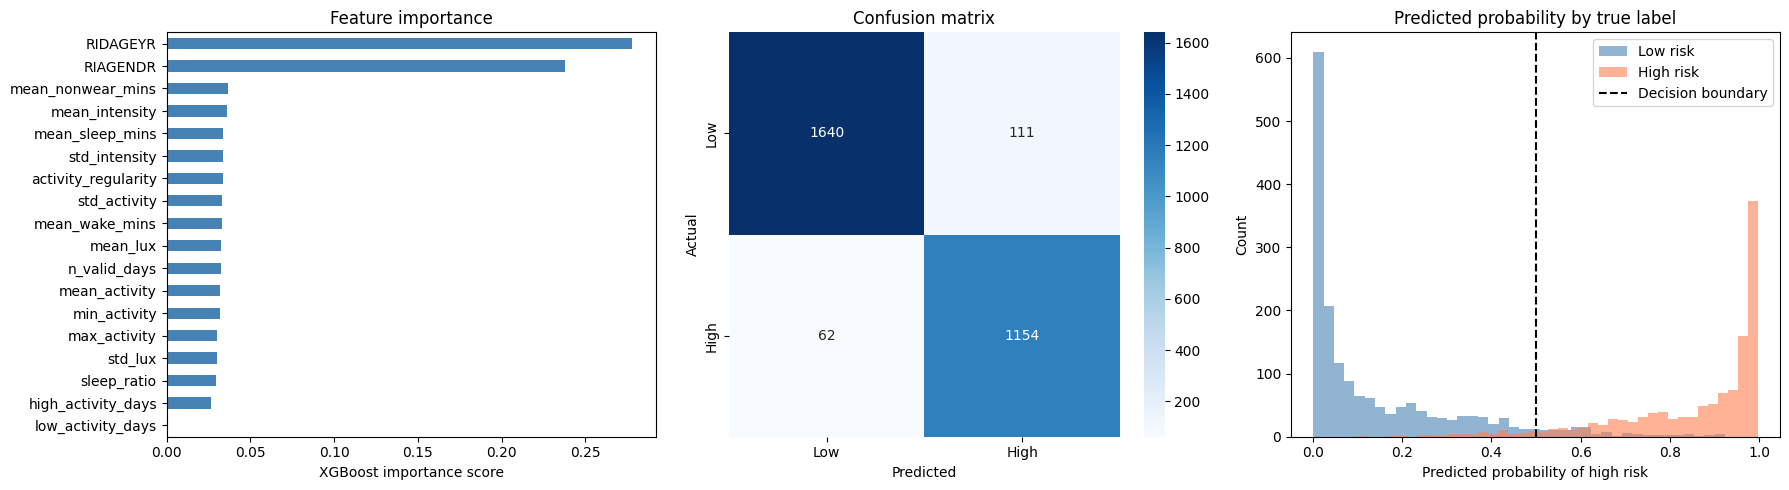


Top 5 most important features:
RIDAGEYR             0.277977
RIAGENDR             0.237668
mean_nonwear_mins    0.036868
mean_intensity       0.035876
mean_sleep_mins      0.033744
dtype: float32


In [29]:
importance = plot_results(trained_model, X, y, y_proba)
print("\nTop 5 most important features:")
print(importance.sort_values(ascending=False).head())

In [30]:
from model import prepare_xy
from sklearn.model_selection import StratifiedKFold, cross_val_score
import xgboost as xgb

# Drop age and sex — pure wearable signal only
X_pure = X.drop(columns=['RIDAGEYR', 'RIAGENDR'])

model_pure = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y==0).sum()/(y==1).sum(),
    random_state=42, verbosity=0
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_pure = cross_val_score(model_pure, X_pure, y, cv=cv, scoring='roc_auc')

print("=== Wearable-only (no age/sex) ===")
print(f"AUC: {auc_pure.mean():.3f} (+/- {auc_pure.std():.3f})")
print("\n=== With age + sex ===")
auc_full = cross_val_score(trained_model, X, y, cv=cv, scoring='roc_auc')
print(f"AUC: {auc_full.mean():.3f} (+/- {auc_full.std():.3f})")

=== Wearable-only (no age/sex) ===
AUC: 0.650 (+/- 0.017)

=== With age + sex ===
AUC: 0.916 (+/- 0.008)


In [32]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb

# Train pure wearable model
model_pure = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y==0).sum()/(y==1).sum(),
    random_state=42, verbosity=0
)
X_pure = X.drop(columns=['RIDAGEYR', 'RIAGENDR'])
model_pure.fit(X_pure, y)

# Permutation importance — shuffles each feature and measures AUC drop
perm = permutation_importance(
    model_pure, X_pure, y,
    n_repeats=20,
    scoring='roc_auc',
    random_state=42
)

perm_df = pd.DataFrame({
    'feature':    X_pure.columns,
    'importance': perm.importances_mean,
    'std':        perm.importances_std
}).sort_values('importance', ascending=True)

print("Feature importances (AUC drop when feature is shuffled):")
print(perm_df.sort_values('importance', ascending=False).to_string(index=False))

Feature importances (AUC drop when feature is shuffled):
            feature  importance      std
     mean_intensity    0.154147 0.005776
           mean_lux    0.047528 0.002372
       min_activity    0.044414 0.002728
      mean_activity    0.044106 0.001993
      std_intensity    0.041983 0.003114
  mean_nonwear_mins    0.041013 0.002560
        sleep_ratio    0.038989 0.002261
            std_lux    0.032767 0.001869
    mean_sleep_mins    0.031681 0.001548
     mean_wake_mins    0.025686 0.001532
       std_activity    0.025226 0.001516
       max_activity    0.024879 0.001372
activity_regularity    0.013173 0.000683
       n_valid_days    0.001413 0.000164
 high_activity_days    0.001090 0.000226
  low_activity_days    0.000194 0.000082


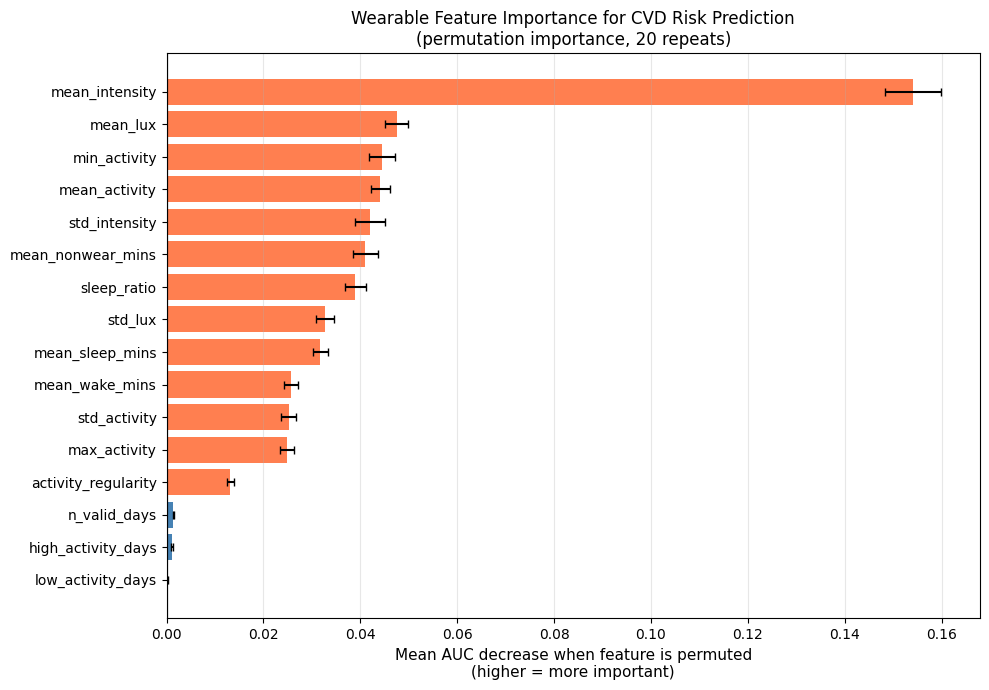

In [33]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['coral' if v > 0.005 else 'steelblue' for v in perm_df['importance']]

ax.barh(perm_df['feature'], perm_df['importance'],
        xerr=perm_df['std'], color=colors,
        align='center', capsize=3)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean AUC decrease when feature is permuted\n(higher = more important)', fontsize=11)
ax.set_title('Wearable Feature Importance for CVD Risk Prediction\n(permutation importance, 20 repeats)', fontsize=12)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

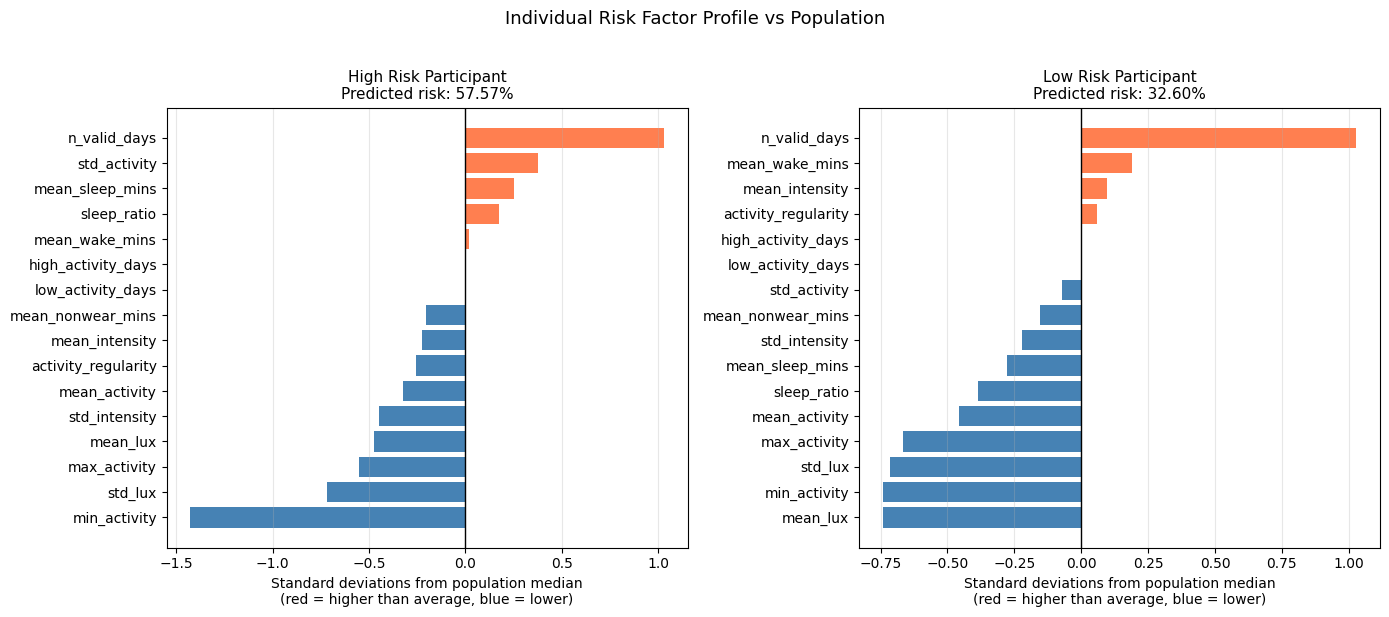

In [34]:
# Show what drives a high vs low risk individual prediction
high_idx = y[y==1].index[0]
low_idx  = y[y==0].index[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, idx, label, color in zip(
    axes,
    [high_idx, low_idx],
    ['High Risk Participant', 'Low Risk Participant'],
    ['coral', 'steelblue']
):
    patient = X_pure.loc[idx]
    # Normalize each feature relative to population median
    medians = X_pure.median()
    stds    = X_pure.std().replace(0, 1)
    deviation = ((patient - medians) / stds).sort_values()

    bar_colors = ['coral' if v > 0 else 'steelblue' for v in deviation]
    ax.barh(deviation.index, deviation.values, color=bar_colors)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(f'{label}\nPredicted risk: {model_pure.predict_proba(X_pure.loc[[idx]])[0,1]:.2%}',
                 fontsize=11)
    ax.set_xlabel('Standard deviations from population median\n(red = higher than average, blue = lower)')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Individual Risk Factor Profile vs Population', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../results/individual_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import coremltools as ct
import numpy as np

# Convert XGBoost model to Core ML


feature_names = X_pure.columns.tolist()

# Convert using the newer API
coreml_model = ct.converters.xgboost.convert(
    model_pure,
    feature_names=feature_names,
    target_feature_name='high_cvd_risk',
    mode='classifier'
)

# Add metadata — this is what makes it look professional
coreml_model.author       = 'Arya Bhanushali'
coreml_model.license      = 'MIT'
coreml_model.short_description = (
    'Predicts 10-year cardiovascular disease risk from '
    'passively collected wearable sensor data. '
    'No blood draw required. Designed for on-device '
    'inference via Apple Watch to preserve user privacy.'
)

# Document each input feature
for name in feature_names:
    coreml_model.input_description[name] = f'Wearable-derived feature: {name}'

coreml_model.output_description['high_cvd_risk'] = (
    'Binary CVD risk classification: 1 = high risk (>=10% 10-year risk)'
)

# Save it
coreml_model.save('../results/CVDRiskWearable.mlmodel')
print("Saved to results/CVDRiskWearable.mlmodel")
print(coreml_model)

scikit-learn version 1.8.0 is not supported. Minimum required version: 0.17. Maximum required version: 1.5.1. Disabling scikit-learn conversion API.
XGBoost version 3.2.0 has not been tested with coremltools. You may run into unexpected errors. XGBoost 1.4.2 is the most recent version that has been tested.
Failed to load _MLModelProxy: No module named 'coremltools.libcoremlpython'
Failed to load _MLCPUComputeDeviceProxy: No module named 'coremltools.libcoremlpython'
Failed to load _MLGPUComputeDeviceProxy: No module named 'coremltools.libcoremlpython'
Failed to load _MLNeuralEngineComputeDeviceProxy: No module named 'coremltools.libcoremlpython'
Failed to load _MLModelProxy: No module named 'coremltools.libcoremlpython'
Failed to load _MLComputePlanProxy: No module named 'coremltools.libcoremlpython'
Fail to import BlobReader from libmilstoragepython. No module named 'coremltools.libmilstoragepython'
Failed to load _MLModelProxy: No module named 'coremltools.libcoremlpython'
Failed to 

TypeError: convert() got an unexpected keyword argument 'target_feature_name'